## Workflow & Objective

This notebook demonstrates how to apply the Probabilistic Error Reduction (PER) technique using a Sparse Pauli–Lindblad noise model to mitigate hardware noise in a Variational Quantum Eigensolver (VQE).

We use a 4-site Mixed Field Ising Model (MFIM) and evaluate the ground state energy:

1. Ideal backend (shot noise only)

2. Realistic noisy backend (based on IBM hardware snapshots)

3. Mitigated results using Pauli-Lindblad-PER

The method follows the protocol from:

E. van den Berg, Z. K. Minev, A. Kandala, K. Temme $\textit{Probabilistic error cancellation with sparse Pauli–Lindblad model}$


The main idea:
Instead of correcting noise physically → invert its effect statistically through a learned noise model.


## Physical system: 4-site Mixed-Field Ising Model

We study a **4-spin Ising model** on a 2×2 square lattice with transverse and longitudinal fields.  
Each site corresponds to one qubit.

The Hamiltonian is

$$
H = J \sum_{\langle i,j\rangle} Z_i Z_j
+ h_x \sum_i X_i
+ h_z \sum_i Z_i
$$

where
- $J$ couples nearest neighbors,
- $h_x$ drives quantum fluctuations,
- $h_z$ breaks spin-flip symmetry.

The geometry is fixed to the following square lattice:


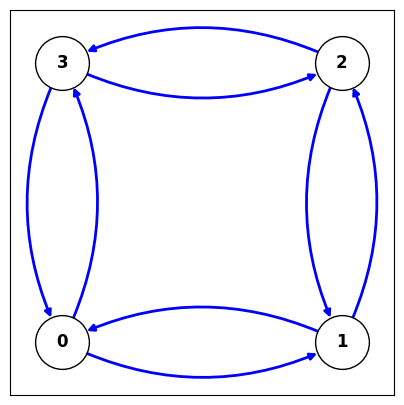

<Axes: >

In [3]:
import sys; sys.path.append('../..')
import numpy as np
from src.plot_helpers import plot_topology

topology = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])
plot_topology(topology)

## Variational Quantum Eigensolver (noise-free reference)

Before studying hardware noise and mitigation, we first solve the problem in an **ideal setting**.

We use:
- A **Hamiltonian Variational Ansatz (HVA)** tailored to the Ising model
- One variational layer
- Shot-based measurement (to mimic real experiments, but without hardware noise)

This step provides:
1. An approximate ground-state energy
2. Optimal circuit parameters
3. Exact Pauli expectation values from the resulting quantum state

These values will serve as the **reference** when we later introduce noise and mitigation.


In [12]:
from src.VQE_functions import optimize_energy, MFIM_Hamiltonian, build_hva_layers
from scipy.linalg import eigh
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, SparsePauliOp

topology = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])

hx = 1
hz = 1
J = -1

Hamiltonian = MFIM_Hamiltonian(J=J, hx=hx, hz=hz, topology = topology)
pauli_list = [p.to_label() for p in Hamiltonian.paulis]
hva_layers, params = build_hva_layers(topology=topology, num_layers=1)

backend = AerSimulator()

num_layers = 1
initial_params = [1,1,1]
bounds = [(-np.pi, np.pi)] * 3*num_layers

opt_params, energy, HelperInfo = optimize_energy(initial_params=initial_params, Hamiltonian=Hamiltonian, 
                                                 topology=topology, num_layers=num_layers, backend=backend, 
                                                 mode="measurement",bounds = bounds, shots=1024)

values = {p: v for p, v in zip(params, opt_params)}
qc_bound = hva_layers.assign_parameters(values)

print(qc_bound.draw(fold=-1))

exact_energy = np.min(eigh(Hamiltonian.to_matrix(), eigvals_only=True))

psi = Statevector.from_instruction(qc_bound)
expectation_values = []
for pauli_str in pauli_list:
    op = SparsePauliOp.from_list([(pauli_str, 1.0)])
    expval = np.real(psi.expectation_value(op))
    expectation_values.append(expval)

print("Measured energy: ",energy)
print("Relative error: ", np.abs(energy - exact_energy) / np.abs(exact_energy) *100, "%")
print("Initial parameters: ",initial_params)
print("Optimal parameters: ", opt_params)


     ┌───┐┌─────────────┐┌───────────┐                                                                   
q_0: ┤ H ├┤ Rz(-1.4065) ├┤ Rx(1.283) ├──■──────────────────■────■────────────────────────────────■───────
     ├───┤├─────────────┤├───────────┤┌─┴─┐┌────────────┐┌─┴─┐  │                                │       
q_1: ┤ H ├┤ Rz(-1.4065) ├┤ Rx(1.283) ├┤ X ├┤ Rz(1.0543) ├┤ X ├──┼────────■───────────────────────┼────■──
     ├───┤├─────────────┤├───────────┤└───┘└────────────┘└───┘  │      ┌─┴─┐     ┌────────────┐  │  ┌─┴─┐
q_2: ┤ H ├┤ Rz(-1.4065) ├┤ Rx(1.283) ├──■──────────────────■────┼──────┤ X ├─────┤ Rz(1.0543) ├──┼──┤ X ├
     ├───┤├─────────────┤├───────────┤┌─┴─┐┌────────────┐┌─┴─┐┌─┴─┐┌───┴───┴────┐└────────────┘┌─┴─┐└───┘
q_3: ┤ H ├┤ Rz(-1.4065) ├┤ Rx(1.283) ├┤ X ├┤ Rz(1.0543) ├┤ X ├┤ X ├┤ Rz(1.0543) ├──────────────┤ X ├─────
     └───┘└─────────────┘└───────────┘└───┘└────────────┘└───┘└───┘└────────────┘              └───┘     
Measured energy:  -8.71484375
Relative error: 

## Realistic hardware noise model

To emulate real quantum hardware, we use a snapshot of an IBM quantum processor:
**FakeWashingtonV2**.

This backend provides:
- The real device connectivity graph
- Calibrated single- and two-qubit gate errors
- Decoherence and readout noise

Using this backend inside Qiskit Aer gives us a **faithful simulation of real hardware behavior**, without needing access to the physical QPU.

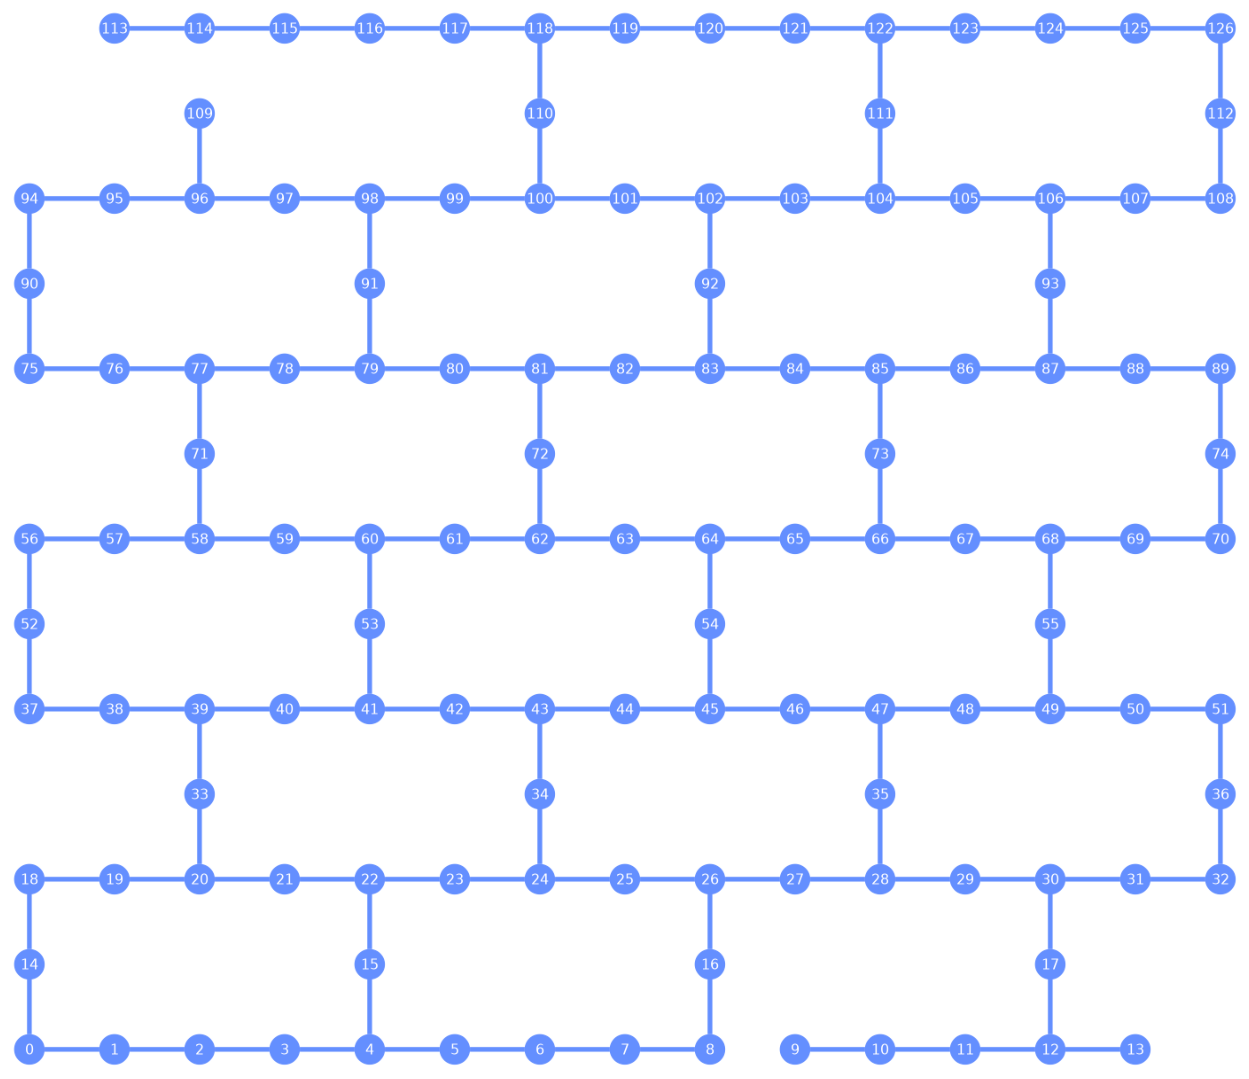

In [20]:
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.visualization import plot_gate_map

fake_backend = FakeWashingtonV2()
noise_model = NoiseModel.from_backend(fake_backend)
backend_noisy = AerSimulator(noise_model=noise_model)

plot_gate_map(fake_backend) # plot the gate map of our chosen backend

Working on a 127‑qubit device but only needing 4 qubits creates a routing issue. Qiskit’s transpiler tries to make every two‑qubit gate physically possible. If you don’t say otherwise, it can route gates through many other qubits, adding SWAPs on distant hardware links. Those extra hops change the error rates you see, so you no longer measure the real behavior of the four qubits you care about.

To fix this issue one needs to tell Qiskit to stay inside a chosen 4‑qubit neighborhood and keep the logical qubits pinned to those physical qubits. The transpiler can still add SWAPs, but only among those four, so any noise you observe comes from that small patch of hardware.

Pick four physical qubits that are connected on the device (so their two‑qubit links exist on the chip).
Build a coupling map that includes only those four qubits and their edges.
Transpililation is done in the background with a fixed initial layout pointing the logical qubits to those four physical qubits, and give the restricted coupling map.

If transpilation errors, it means the chosen four qubits don’t support the needed two‑qubit connectionsPick another connected set or tweak the circuit. 

In [18]:
phys_qubits = [0,1,2,3]

## Running the circuit on noisy hardware

We now execute the same optimized circuit on the noisy backend.

At this point:
- The circuit parameters are still optimal for the ideal system
- Only the **hardware noise** is new

Any deviation from the exact energy therefore comes purely from:
- Gate errors
- Decoherence
- Readout noise

This establishes the baseline that probabilistic error cancellation must improve upon.


In [19]:
from src.VQE_functions import compute_exp_value

energy_noisy = compute_exp_value(qc_bound,Hamiltonian,fake_backend,phys_qubits=phys_qubits)

print("Measured energy: ",np.real(energy_noisy))
print("Relative error: ", np.abs(energy_noisy - exact_energy) / np.abs(exact_energy) *100, "%")

Measured energy:  -7.470703125
Relative error:  13.792475070310875 %


## Learning the noise model (Sparse Pauli–Lindblad tomography)

Probabilistic Error Reduction requires an **explicit noise model**.

We approximate the hardware noise by a **sparse Pauli–Lindblad channel**:
$$
\mathcal{E}(\rho) = \sum_k c_k P_k \rho P_k
$$
where only a small set of Pauli errors $P_k$ have significant weight.

We do **not** include all $4^n$ Pauli operators. Instead, we restrict the support of $P_k$ to at most **two qubits**, reflecting the locality of hardware noise:

- **Single-qubit errors**  
  All Pauli operators $X_i, Y_i, Z_i$ are included for every qubit that appears in the circuit.

- **Two-qubit correlated errors**  
  For every **physically connected qubit pair** $(i,j)$ on the device, we include all Pauli products $P_i \otimes P_j \in \{X,Y,Z\}^{\otimes 2}$, acting on that pair, while **all other qubits are identity**.

This choice captures the dominant physical error mechanisms:
- single-qubit decoherence and control errors  
- two-qubit correlated errors from entangling gates and crosstalk  

while keeping the model **tractable and learnable** from data.

To estimate the coefficients $c_k$, we perform:
- Layer-resolved gate tomography  
- Using randomized circuit sampling  
- On the same physical qubits used for VQE  

This procedure extracts a **compact, physically motivated error model** directly from the device, which can then be inverted statistically via Probabilistic Error Reduction.



In [21]:
from pauli_lindblad_per.tomography.experiment import SparsePauliTomographyExperiment as tomography
from qiskit.primitives import BackendSamplerV2

shots = 1024
sampler = BackendSamplerV2(backend = fake_backend, options={"default_shots":shots})

experiment = tomography(
    circuits = [qc_bound], #list of circuits from which to get the layers requiring tomography
    backend = fake_backend, #quantum backend
    phys_qubits=phys_qubits # physical Qubits on which all operations will be performed
    )

experiment.generate(
    samples = 50, #Number of samples to take from the fidelity pair measurements
    single_samples = 100, #samples to take from the pair-breaking measurements
    depths = [2,4,8], #values of 2n to make the pair measurements. Numbers must be even and non-zero
    shots = shots
    )

def executor(circuits):
    res = sampler.run(circuits).result()
    list_counts_dict = [r.data.meas.get_counts() for r in res]
    return list_counts_dict

#run the experiment
experiment.run(executor, auto_save=False)
noisedataframe = experiment.analyze()

=== Tomography ===
Circuits:       3900
Backend runs:  3993600
Details:
  N_layers        : 2
  num_meas_bases  : 9
  depth_count     : 3
  samples         : 50
  single_samples  : 100
  sum_single_bases: 12


## Learned error rates

The first plot shows the **Pauli-support infidelities** of the noise channel.
This tells us which error processes dominate on this layer.

The second plot shows the **coefficients of the sparse Pauli–Lindblad model**.
These are the parameters used later to invert the noise statistically.


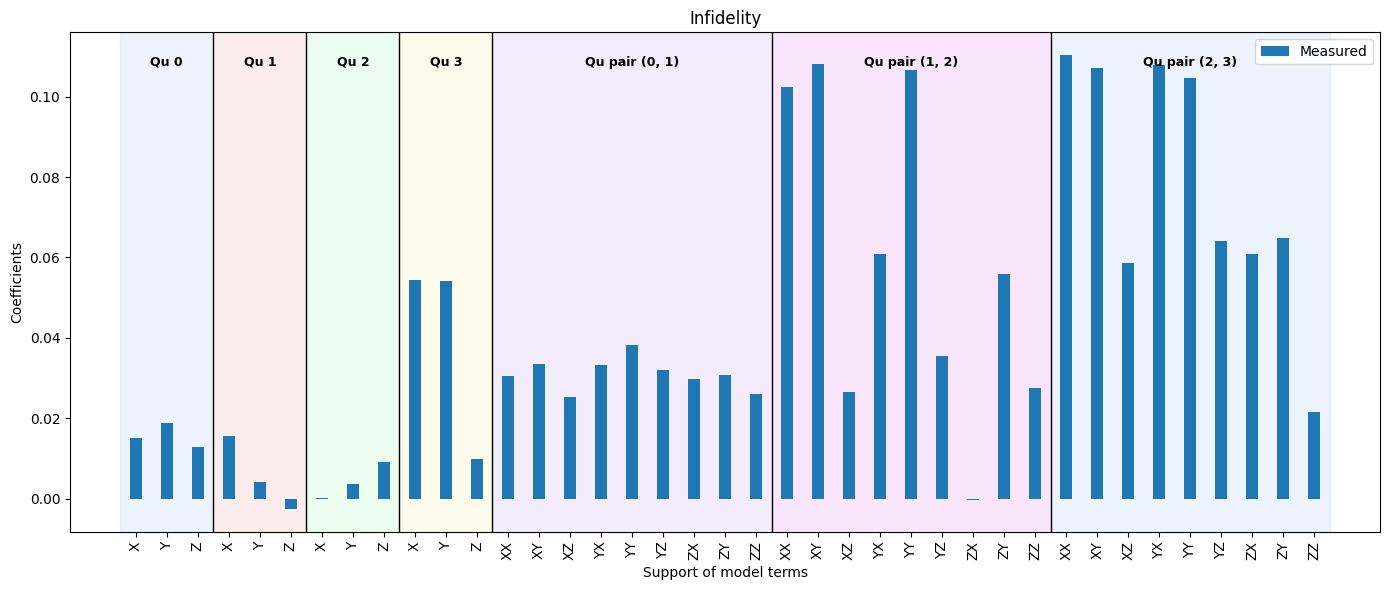

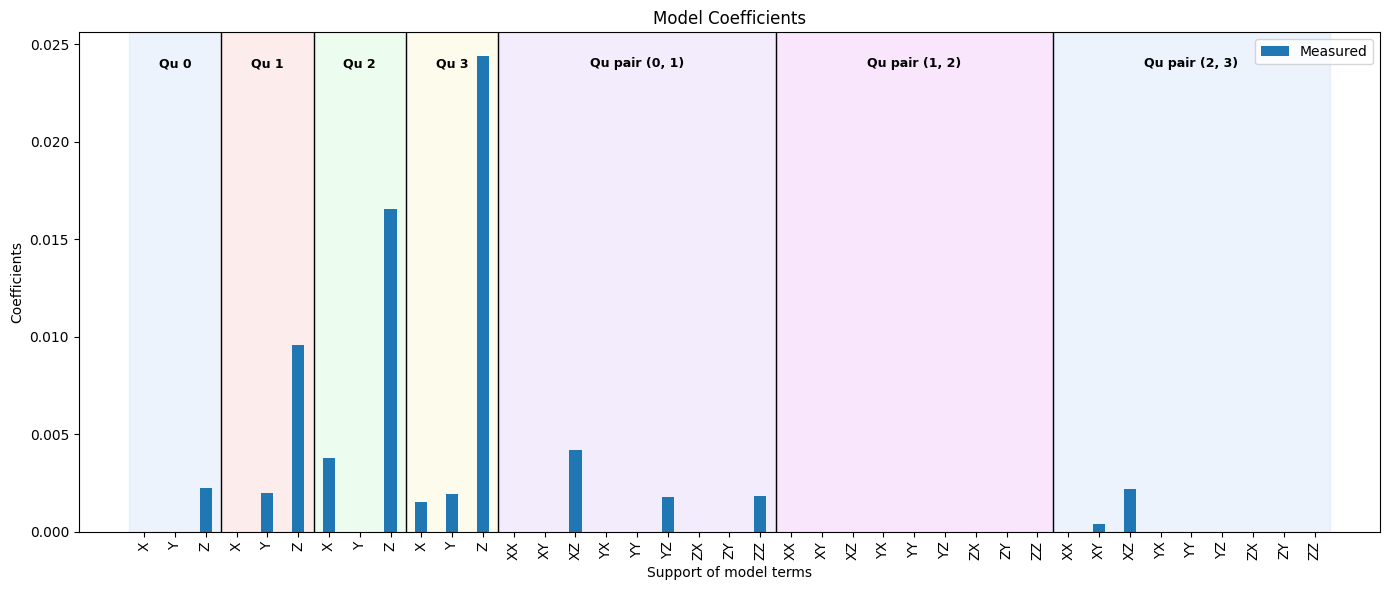

In [33]:
layer1 = experiment.analysis.get_layer_data(layer=0)
layer1.plot_infidelitites()
layer1.plot_coeffs()

## Probabilistic Error Reduction with Zero-Noise Extrapolation

Using the learned Pauli-Lindblad model, we construct a **quasi-probability representation** of the inverse noise channel.

In practice:
- We resample noisy circuits using signed Pauli corrections
- This produces unbiased estimates of ideal expectation values
- At the cost of increased statistical variance

We further combine this with **Zero-Noise Extrapolation (ZNE)** by artificially amplifying noise and extrapolating back to zero.


In [ ]:
perexp = experiment.create_per_experiment([qc_bound])

perexp.generate(
    expectations=pauli_list,
    samples=1000, 
    noise_strengths=[0, 1, 2],
    shots = shots
)
perexp.run(executor)


=== PER ===
Circuits:       6000
Backend runs:  6144000
Details:
  num_meas_bases_per : 2
  num_noise_strengths: 3
  samples            : 1000


Aus SV-Simulation:  0.8948374561528492


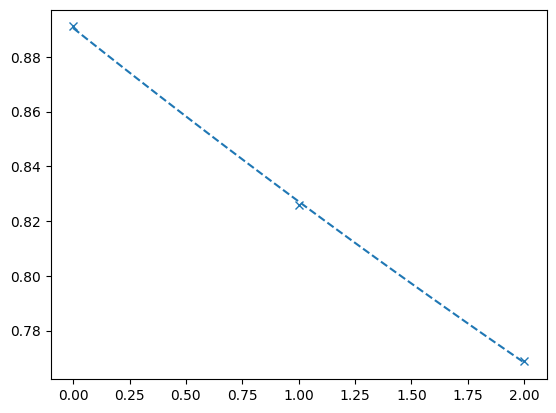

In [ ]:
per_results = perexp.analyze() # analyze the results
result_1 = per_results[0].get_result(pauli_list[2]).plot() # get the ZNE results
print("Aus SV-Simulation: ",expectation_values[2])

## Final comparison

We now compare three energies with the exact energy (from solving the eigenvalue problem):

1. Ideal simulator
2. Noisy hardware
3. Noisy hardware with PER + ZNE

The improvement demonstrates that:
- The sparse Pauli–Lindblad model captures the dominant errors
- PER successfully removes them

In [ ]:
exp_val_per = np.zeros((len(pauli_list)))
energy_per = 0

# Compare absolute vs relative errors
for k in range(len(pauli_list)):
    exact = expectation_values[k]
    exp_val_per[k] = per_results[0].get_result(pauli_list[k]).get_expectations()[0]
    abs_error = abs(exact - exp_val_per[k])
    rel_error = abs_error / abs(exact) if exact != 0 else float('inf')

    energy_per += Hamiltonian.coeffs[k]*exp_val_per[k]

print("Relative error in the energy for ideal backend: ", np.abs(energy - exact_energy) / np.abs(exact_energy) *100, "%")
print("Relative error in the energy for noisy backend: ", np.abs(energy_noisy - exact_energy) / np.abs(exact_energy) *100, "%")
print("Relative error in the energy for noisy backend (with PER): ", np.abs(energy_per - exact_energy) / np.abs(exact_energy) *100, "%")

Relative error in the energy for ideal backend:  0.5641767937968312 %
Relative error in the energy for noisy backend:  13.792475070310875 %
Relative error in the energy for noisy backend (with PER):  1.4444252237896837 %
